

#  Global Life Expectancy Prediction & Socio-Economic Analysis
**Team Members:**
- Islam Shehta Mohamed
- Ahmed Hossam Awad
- Aser Esam Abdellatif
- Mohamed Mohamed Reda


**Project Type:** Supervised Machine Learning (Regression)

**Data Source:** WHO & World Bank (Fixed/Updated Dataset)

---

##  Project Overview & Objective
This project aims to predict and analyze the factors affecting **Life Expectancy** across 179 countries from 2000 to 2015. By leveraging clinical, economic, and demographic indicators, we build and compare multiple regression models—ranging from baseline linear models to regularized (Lasso/Ridge) and non-linear models (Random Forest)—to identify the most robust predictors of human longevity.

---

##  Dataset Features Dictionary (The 22 Columns Explained)

The dataset contains **2,864 rows** and **21 features + 1 Target Variable**. Below is the detailed dictionary for all columns:

### 1. Target Variable (What we are predicting)
* `Life_expectancy` (Continuous): The average number of years a newborn infant is expected to live.

### 2. Demographic & Geographic Features
* `Country` (Categorical): The country of origin (179 countries).
* `Region` (Categorical): The geographical region (e.g., Africa, European Union, Asia).
* `Year` (Numerical): The year of observation (2000–2015).
* `Population` (Numerical): Total population of the country.

### 3. Economic & Socio-Economic Indicators
* `GDP_per_capita` (Numerical): Gross Domestic Product per capita (in USD).
* `Schooling` (Numerical): Average number of years of schooling/education of the citizens.
* `Economy_status_Developed` (Binary): 1 if the country is developed, 0 if developing.
* `Economy_status_Developing` (Binary): 1 if the country is developing, 0 if developed.

### 4. Health, Mortality & Lifestyle Indicators
* `Adult_mortality` (Numerical): Adult mortality rates (probability of dying between 15 and 60 years per 1000 population).
* `Infant_deaths` (Numerical): Infant deaths (number of infant deaths per 1000 live births).
* `Under_five_deaths` (Numerical): Number of under-five deaths per 1000 live births.
* `Alcohol_consumption` (Numerical): Alcohol consumption per capita (recorded in liters of pure alcohol).
* `BMI` (Numerical): Average Body Mass Index of the entire population.
* `Thinness_ten_nineteen_years` (Numerical): Prevalence of thinness among children aged 10 to 19 years (%).
* `Thinness_five_nine_years` (Numerical): Prevalence of thinness among children aged 5 to 9 years (%).

### 5. Immunization & Disease Prevention Coverages
* `Hepatitis_B` (Numerical): Hepatitis B immunization coverage among 1-year-olds (%).
* `Measles` (Numerical): Measles immunization coverage among 1-year-olds (%).
* `Polio` (Numerical): Polio (Pol3) immunization coverage among 1-year-olds (%).
* `Diphtheria` (Numerical): Diphtheria, tetanus toxoid, and pertussis (DTP3) immunization coverage among 1-year-olds (%).
* `Incidents_HIV` (Numerical): Incidents of HIV per 1000 population.

---

##  Project Execution Workflow (The Pipeline)
1.  **Exploratory Data Analysis (EDA):** Correlation analysis, distribution plots, and outlier detection.
2.  **Preprocessing:** Feature scaling (StandardScaler) and handling categorical variables.
3.  **Model Training:**
    * *Baseline:* Multiple Linear Regression
    * *Regularization:* Lasso (L1) & Ridge (L2) Regressions
    * *Complexity:* Polynomial Features (Degree 2)
    * *Ensemble:* Random Forest Regressor (Non-Linear)
4.  **Evaluation:** Comparing models using $R^2$, MAE, and RMSE metrics.


# **1-Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score

## **2-Load and Explore the Data**

In [3]:
Life_Expectancy = pd.read_csv("C:\\Users\\moham\\Downloads\\Life-Expectancy-Data-Updated.csv")

##making a copy

In [4]:
Life_Expectancy_copy=Life_Expectancy.copy()

##visualize the data

In [5]:
Life_Expectancy_copy.describe()

,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
count,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000,2864.000000
mean,2007.500000,30.363792,42.938268,192.251775,4.820882,84.292598,77.344972,25.032926,86.499651,86.271648,0.894288,11540.924930,36.675915,4.865852,4.899825,7.632123,0.206704,0.793296,68.856075
std,4.610577,27.538117,44.569974,114.910281,3.981949,15.995511,18.659693,2.193905,15.080365,15.534225,2.381389,16934.788931,136.485867,4.438234,4.525217,3.171556,0.405012,0.405012,9.405608
min,2000.000000,1.800000,2.300000,49.384000,0.000000,12.000000,10.000000,19.800000,8.000000,16.000000,0.010000,148.000000,0.080000,0.100000,0.100000,1.100000,0.000000,0.000000,39.400000
25%,2003.750000,8.100000,9.675000,106.910250,1.200000,78.000000,64.000000,23.200000,81.000000,81.000000,0.080000,1415.750000,2.097500,1.600000,1.600000,5.100000,0.000000,1.000000,62.700000
50%,2007.500000,19.600000,23.100000,163.841500,4.020000,89.000000,83.000000,25.500000,93.000000,93.000000,0.150000,4217.000000,7.850000,3.300000,3.400000,7.800000,0.000000,1.000000,71.400000
75%,2011.250000,47.350000,66.000000,246.791375,7.777500,96.000000,93.000000,26.400000,97.000000,97.000000,0.460000,12557.000000,23.687500,7.200000,7.300000,10.300000,0.000000,1.000000,75.400000
max,2015.000000,138.100000,224.900000,719.360500,17.870000,99.000000,99.000000,32.100000,99.000000,99.000000,21.680000,112418.000000,1379.860000,27.700000,28.600000,14.100000,1.000000,1.000000,83.800000


## showing information

In [6]:
Life_Expectancy_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      2864 non-null   str    
 1   Region                       2864 non-null   str    
 2   Year                         2864 non-null   int64  
 3   Infant_deaths                2864 non-null   float64
 4   Under_five_deaths            2864 non-null   float64
 5   Adult_mortality              2864 non-null   float64
 6   Alcohol_consumption          2864 non-null   float64
 7   Hepatitis_B                  2864 non-null   int64  
 8   Measles                      2864 non-null   int64  
 9   BMI                          2864 non-null   float64
 10  Polio                        2864 non-null   int64  
 11  Diphtheria                   2864 non-null   int64  
 12  Incidents_HIV                2864 non-null   float64
 13  GDP_per_capita               

## showing first 5 rows

In [7]:
Life_Expectancy_copy.head(5)

,Country,Region,Year,Infant_deaths,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,...,Diphtheria,Incidents_HIV,GDP_per_capita,Population_mln,Thinness_ten_nineteen_years,Thinness_five_nine_years,Schooling,Economy_status_Developed,Economy_status_Developing,Life_expectancy
0,Turkiye,Middle East,2015,11.1,13.0,105.8240,1.32,97,65,27.8,...,97,0.08,11006,78.53,4.9,4.8,7.8,0,1,76.5
1,Spain,European Union,2015,2.7,3.3,57.9025,10.35,97,94,26.0,...,97,0.09,25742,46.44,0.6,0.5,9.7,1,0,82.8
2,India,Asia,2007,51.5,67.9,201.0765,1.57,60,35,21.2,...,64,0.13,1076,1183.21,27.1,28.0,5.0,0,1,65.4
3,Guyana,South America,2006,32.8,40.5,222.1965,5.68,93,74,25.3,...,93,0.79,4146,0.75,5.7,5.5,7.9,0,1,67.0
4,Israel,Middle East,2012,3.4,4.3,57.9510,2.89,97,89,27.0,...,94,0.08,33995,7.91,1.2,1.1,12.8,1,0,81.7


## showing shape

In [8]:
Life_Expectancy_copy.shape

(2864, 21)

##showing number of nulls in each column

In [9]:
Life_Expectancy_copy.isnull().sum()

Country                        0
Region                         0
Year                           0
Infant_deaths                  0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Population_mln                 0
Thinness_ten_nineteen_years    0
Thinness_five_nine_years       0
Schooling                      0
Economy_status_Developed       0
Economy_status_Developing      0
Life_expectancy                0
dtype: int64

#**3-Data cleaning**

## deleting unwanted columns

In [10]:

Life_Expectancy_copy = Life_Expectancy_copy.drop(columns=['Country','Economy_status_Developing','Infant_deaths','Thinness_five_nine_years','Population_mln'], errors='ignore')


In [11]:
Life_Expectancy_copy.columns

Index(['Region', 'Year', 'Under_five_deaths', 'Adult_mortality',
       'Alcohol_consumption', 'Hepatitis_B', 'Measles', 'BMI', 'Polio',
       'Diphtheria', 'Incidents_HIV', 'GDP_per_capita',
       'Thinness_ten_nineteen_years', 'Schooling', 'Economy_status_Developed',
       'Life_expectancy'],
      dtype='str')

# **checking nulls**

In [12]:
Life_Expectancy_copy.isnull().sum()

Region                         0
Year                           0
Under_five_deaths              0
Adult_mortality                0
Alcohol_consumption            0
Hepatitis_B                    0
Measles                        0
BMI                            0
Polio                          0
Diphtheria                     0
Incidents_HIV                  0
GDP_per_capita                 0
Thinness_ten_nineteen_years    0
Schooling                      0
Economy_status_Developed       0
Life_expectancy                0
dtype: int64

there is no nulls

##checking duplicates

In [13]:
Life_Expectancy_copy.duplicated().sum()

np.int64(0)

no duplicates in dataset

##checking if there duplicates in columns

In [14]:
print(f"Unique values for {'Region'}: {Life_Expectancy_copy['Region'].unique()}")

print(f"Unique values for {'Economy_status_Developed'}: {Life_Expectancy_copy['Economy_status_Developed'].unique()}")



Unique values for Region: <StringArray>
[                  'Middle East',                'European Union',
                          'Asia',                 'South America',
 'Central America and Caribbean',                'Rest of Europe',
                        'Africa',                       'Oceania',
                 'North America']
Length: 9, dtype: str
Unique values for Economy_status_Developed: [0 1]


##there is no duplicates in these columns

##Encoding



In [15]:
Life_Expectancy_copy = pd.get_dummies(Life_Expectancy_copy, columns=['Region'], drop_first=True)

In [16]:
Life_Expectancy_copy.head(5)

,Year,Under_five_deaths,Adult_mortality,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,...,Economy_status_Developed,Life_expectancy,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America
0,2015,13.0,105.8240,1.32,97,65,27.8,97,97,0.08,...,0,76.5,False,False,False,True,False,False,False,False
1,2015,3.3,57.9025,10.35,97,94,26.0,97,97,0.09,...,1,82.8,False,False,True,False,False,False,False,False
2,2007,67.9,201.0765,1.57,60,35,21.2,67,64,0.13,...,0,65.4,True,False,False,False,False,False,False,False
3,2006,40.5,222.1965,5.68,93,74,25.3,92,93,0.79,...,0,67.0,False,False,False,False,False,False,False,True
4,2012,4.3,57.9510,2.89,97,89,27.0,94,94,0.08,...,1,81.7,False,False,False,True,False,False,False,False


In [17]:
Life_Expectancy_copy.to_csv('Life_Expectancy_copy.csv', index=False)

#**4-EDA**

##Histogram

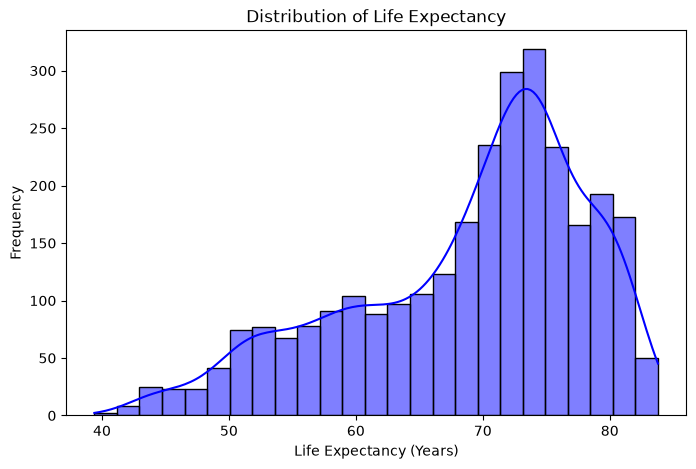

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(Life_Expectancy_copy['Life_expectancy'], kde=True, color='blue')
plt.title('Distribution of Life Expectancy')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Frequency')
plt.show()

## Box plot

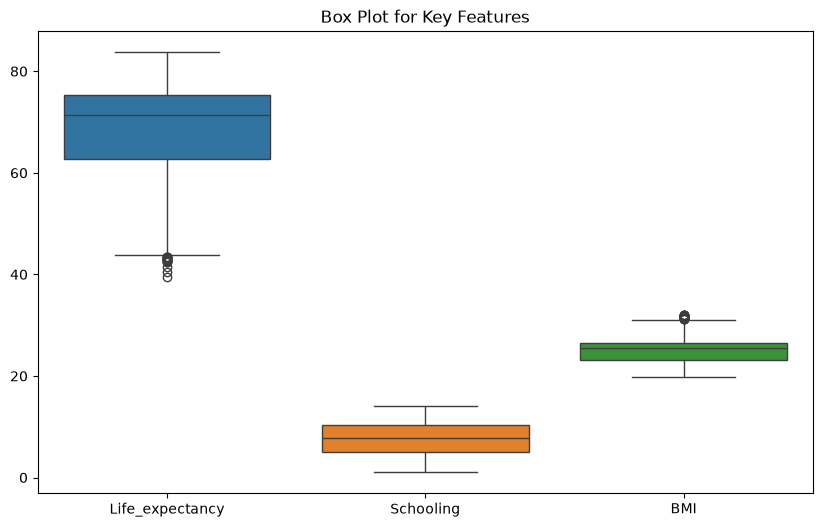

In [19]:

plt.figure(figsize=(10, 6))
sns.boxplot(data=Life_Expectancy_copy[['Life_expectancy', 'Schooling', 'BMI']])
plt.title('Box Plot for Key Features')
plt.show()

##correlation

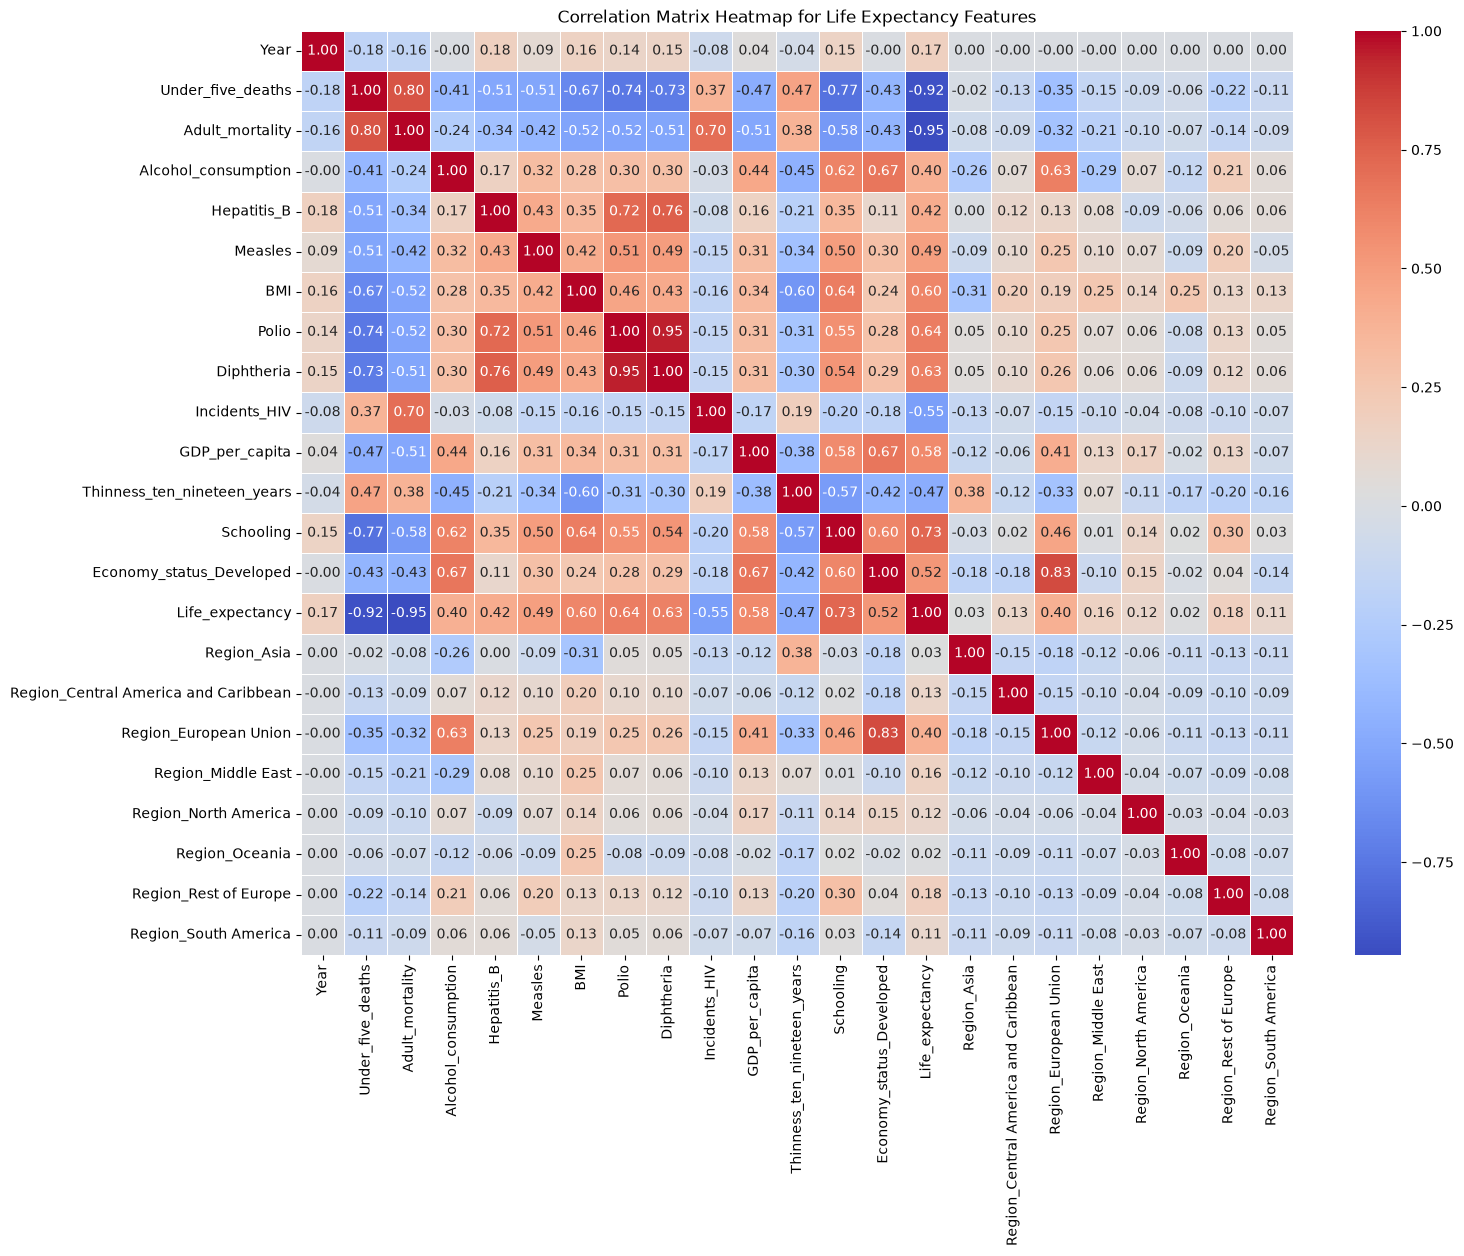

In [20]:
plt.figure(figsize=(16, 12))
sns.heatmap(Life_Expectancy_copy.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap for Life Expectancy Features")
plt.show()

# **5-Feature selection**

In [21]:
X = Life_Expectancy_copy.drop(columns=['Life_expectancy', 'Adult_mortality', 'Under_five_deaths'])
y = Life_Expectancy_copy['Life_expectancy']

# **6-split the data**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scaling

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,Year,Alcohol_consumption,Hepatitis_B,Measles,BMI,Polio,Diphtheria,Incidents_HIV,GDP_per_capita,Thinness_ten_nineteen_years,Schooling,Economy_status_Developed,Region_Asia,Region_Central America and Caribbean,Region_European Union,Region_Middle East,Region_North America,Region_Oceania,Region_Rest of Europe,Region_South America
0,1.380443,-0.597552,0.911076,1.174570,-0.965776,0.822440,0.812860,-0.378718,-0.469740,2.359220,1.016169,-0.510754,2.407949,-0.331633,-0.419617,-0.287582,-0.13499,-0.258019,-0.308422,-0.274931
1,-0.768351,2.152524,0.849564,1.120365,0.714594,0.624325,0.748902,-0.349362,0.132096,-0.622213,1.235473,1.957890,-0.415291,-0.331633,2.383128,-0.287582,-0.13499,-0.258019,-0.308422,-0.274931
2,1.380443,0.442814,-0.380669,0.307277,0.714594,-0.498330,-0.530256,-0.215165,0.247290,-0.736008,0.734206,-0.510754,-0.415291,-0.331633,-0.419617,-0.287582,-0.13499,-0.258019,-0.308422,3.637281
3,0.520925,0.011626,0.911076,1.120365,0.487517,0.822440,0.812860,-0.370331,-0.476527,-0.781526,0.514901,-0.510754,-0.415291,-0.331633,-0.419617,-0.287582,-0.13499,-0.258019,3.242308,-0.274931
4,-0.983230,-0.637662,-0.073111,-0.722634,-0.829530,-0.300214,-0.466298,3.701711,-0.492710,2.131630,-0.581621,-0.510754,-0.415291,-0.331633,-0.419617,-0.287582,-0.13499,-0.258019,-0.308422,-0.274931


# **Model Training & Evaluation**


- Linear Regression

In [24]:
lr_model=LinearRegression()

lr_model.fit(X_train_scaled,y_train)

lr_pred=lr_model.predict(X_test_scaled)


In [25]:
print(lr_pred)

[76.29130834 82.29479707 67.70566062 58.04129014 76.57921611 82.90364752
 74.29073538 61.88080768 73.26108606 86.13113317 60.97907029 67.3625381
 84.9714     73.02456329 75.18756874 56.21693229 72.44742374 78.77061893
 73.53053842 72.33727755 78.27463265 60.06690748 75.17633894 79.12645556
 73.02407667 73.25006871 74.53262571 70.53261573 59.42221604 62.52446453
 61.86437238 75.0034761  77.79956785 48.2787866  61.74232153 72.874518
 63.89563146 76.24385549 50.98833519 61.65782854 69.3904899  72.18229642
 55.4902458  60.56911156 70.30396346 66.9613595  52.88977715 59.79597253
 77.76634965 65.59096406 74.23390884 76.80050959 72.96899898 77.54821239
 79.21263881 65.51832648 60.02130642 76.88301602 71.55027158 62.01818096
 72.31868236 63.00954756 66.54630864 79.91452377 74.21887912 80.52084855
 76.77614103 77.14401899 69.91630691 80.19685726 69.04729022 56.11660845
 76.50155628 70.29426125 69.75519692 71.34685086 70.0092951  66.92362547
 74.83814758 64.09153781 86.41557952 75.81578095 73.70

**Model Score**

In [26]:
train_score = lr_model.score(X_train_scaled, y_train)

test_score = lr_model.score(X_test_scaled, y_test)

print(f"Train Score (R2): {train_score:.4f}")
print(f"Test Score (R2): {test_score:.4f}")

Train Score (R2): 0.8683
Test Score (R2): 0.8416


**Model Coefficients**

In [27]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

                                 Feature  Coefficient
13  Region_Central America and Caribbean     1.898671
19                  Region_South America     1.809246
11              Economy_status_Developed     1.787561
5                                  Polio     1.771343
8                         GDP_per_capita     1.593729
12                           Region_Asia     1.591400
10                             Schooling     1.430352
14                 Region_European Union     1.365181
4                                    BMI     1.332895
15                    Region_Middle East     1.275011
18                 Region_Rest of Europe     1.274602
6                             Diphtheria     0.848400
17                        Region_Oceania     0.656319
0                                   Year     0.628846
16                  Region_North America     0.501385
9            Thinness_ten_nineteen_years     0.332346
3                                Measles     0.265324
2                           

**Linear Coefficient Shrinkage Plot**

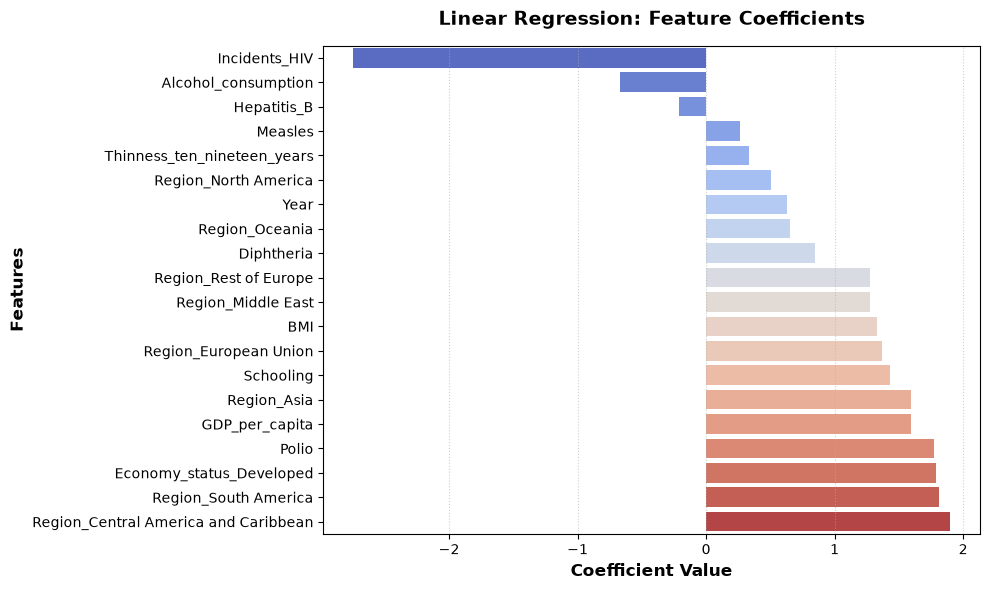

In [28]:
coefs = pd.Series(lr_model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=coefs.values, y=coefs.index, hue=coefs.index, palette="coolwarm", legend=False)
plt.title('Linear Regression: Feature Coefficients', fontsize=14, weight='bold', pad=15)
plt.xlabel('Coefficient Value', fontsize=12, weight='bold')
plt.ylabel('Features', fontsize=12, weight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Lasso Regression**

In [29]:
lasso_model = Lasso(alpha=1.0, random_state=42)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

**Model Score**

In [30]:
train_score = lasso_model.score(X_train_scaled, y_train)

test_score = lasso_model.score(X_test_scaled, y_test)

print(f"Train Score (R2): {train_score:.4f}")
print(f"Test Score (R2): {test_score:.4f}")

Train Score (R2): 0.8041
Test Score (R2): 0.7755


**Model Coefficients**

In [31]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

                                 Feature  Coefficient
10                             Schooling     2.537316
5                                  Polio     1.798755
8                         GDP_per_capita     1.433353
4                                    BMI     1.029421
6                             Diphtheria     0.562321
11              Economy_status_Developed     0.071469
1                    Alcohol_consumption     0.000000
0                                   Year     0.000000
3                                Measles     0.000000
2                            Hepatitis_B     0.000000
9            Thinness_ten_nineteen_years    -0.000000
12                           Region_Asia     0.000000
16                  Region_North America     0.000000
13  Region_Central America and Caribbean     0.000000
14                 Region_European Union     0.000000
15                    Region_Middle East     0.000000
18                 Region_Rest of Europe    -0.000000
17                        Re

**Lasso Coefficient Shrinkage Plot**

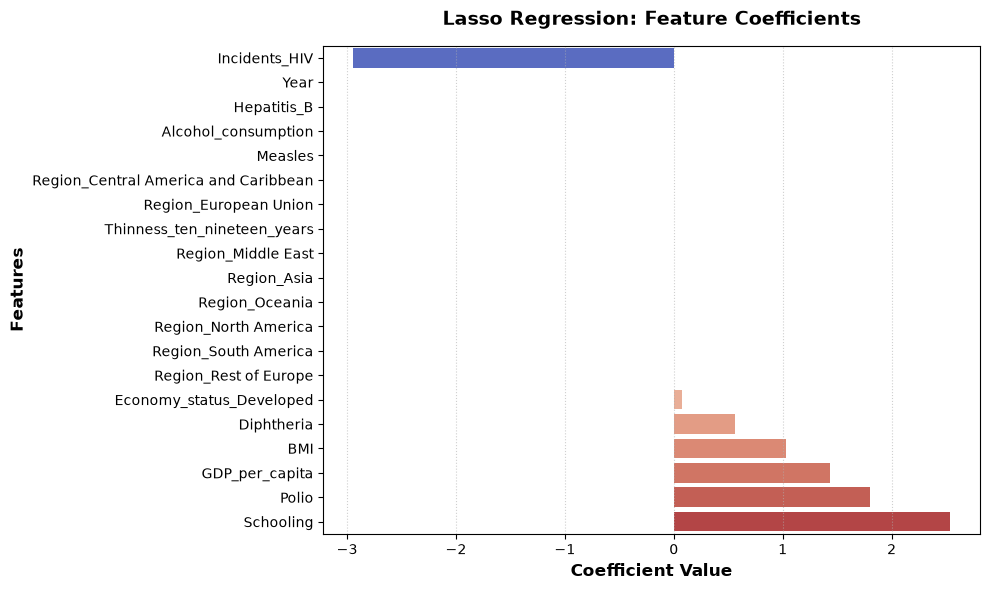

In [32]:
coefs = pd.Series(lasso_model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=coefs.values, y=coefs.index, hue=coefs.index, palette="coolwarm", legend=False)
plt.title('Lasso Regression: Feature Coefficients', fontsize=14, weight='bold', pad=15)
plt.xlabel('Coefficient Value', fontsize=12, weight='bold')
plt.ylabel('Features', fontsize=12, weight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

- **Ridge Regression**

In [33]:

ridge_model =Ridge(alpha=1.0, random_state=42)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)


**Model Score**

In [34]:
train_score = ridge_model.score(X_train_scaled, y_train)

test_score = ridge_model.score(X_test_scaled, y_test)

print(f"Train Score (R2): {train_score:.4f}")
print(f"Test Score (R2): {test_score:.4f}")

Train Score (R2): 0.8683
Test Score (R2): 0.8416


**Model Coefficients**

In [35]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

                                 Feature  Coefficient
13  Region_Central America and Caribbean     1.894615
19                  Region_South America     1.805614
11              Economy_status_Developed     1.785531
5                                  Polio     1.766733
8                         GDP_per_capita     1.593586
12                           Region_Asia     1.588802
10                             Schooling     1.431618
14                 Region_European Union     1.360617
4                                    BMI     1.333762
15                    Region_Middle East     1.272640
18                 Region_Rest of Europe     1.270548
6                             Diphtheria     0.852967
17                        Region_Oceania     0.653946
0                                   Year     0.628030
16                  Region_North America     0.499686
9            Thinness_ten_nineteen_years     0.331116
3                                Measles     0.265769
2                           

**Ridge Coefficient Shrinkage Plot**

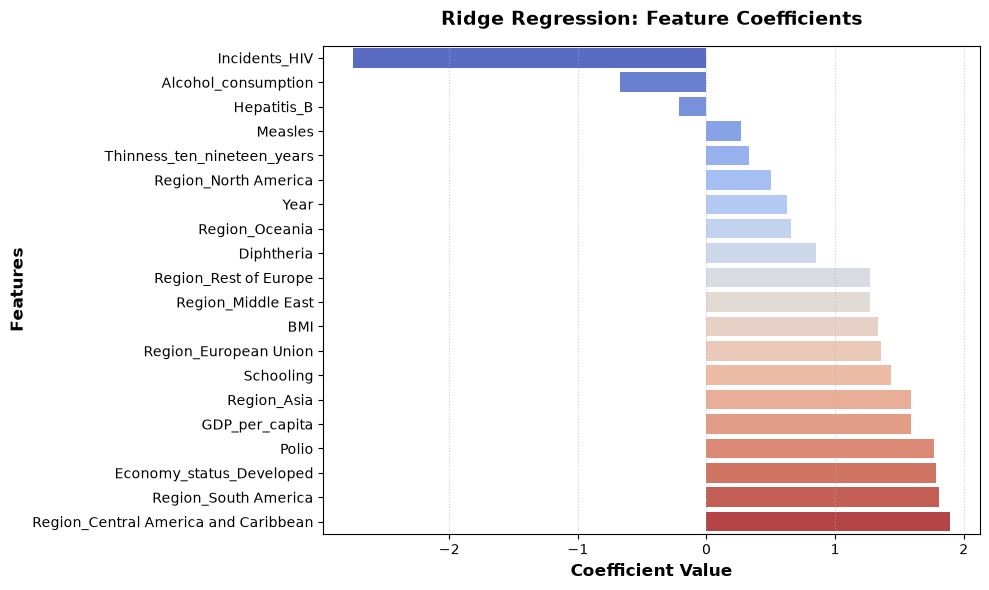

In [36]:
coefs = pd.Series(ridge_model.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=coefs.values, y=coefs.index, hue=coefs.index, palette="coolwarm", legend=False)
plt.title('Ridge Regression: Feature Coefficients', fontsize=14, weight='bold', pad=15)
plt.xlabel('Coefficient Value', fontsize=12, weight='bold')
plt.ylabel('Features', fontsize=12, weight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

- **Polynomial Regression**

In [37]:
poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(X_train_scaled)
x_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()

poly_model.fit(x_train_poly, y_train)

poly_pred = poly_model.predict(x_test_poly)

**Model Score**

In [38]:
train_score = poly_model.score(x_train_poly, y_train)
test_score = poly_model.score(x_test_poly, y_test)
print(f"Train Score (R2): {train_score:.4f}")
print(f"Test Score (R2): {test_score:.4f}")

Train Score (R2): 0.9556
Test Score (R2): 0.9405


- **Random Forest Regression**

In [51]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

**Model Score**

In [52]:
train_score = rf_model.score(X_train, y_train)
test_score = rf_model.score(X_test, y_test )
print(f"Train Score (R2): {train_score:.4f}")
print(f"Test Score (R2): {test_score:.4f}")

Train Score (R2): 0.9971
Test Score (R2): 0.9856


In [41]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross-validation R² scores:", cv_scores)
print("Mean R²:", cv_scores.mean())

Cross-validation R² scores: [0.98897649 0.98551602 0.98501066 0.98701112 0.98854528]
Mean R²: 0.9870119141261082


**Model List Setup**




In [42]:

models_list = [
    ("Linear Regression", lr_model, X_test_scaled),
    ("Lasso", lasso_model, X_test_scaled),
    ("Ridge", ridge_model, X_test_scaled),
    ("Polynomial Regression", poly_model, x_test_poly),
    ("Random Forest", rf_model, X_test)
]

results = []

**Evaluation Loop**

In [43]:
import time

for name, model, data in models_list:
    start = time.time()
    y_pred = model.predict(data)
    end = time.time()

    results.append({
        "Algorithm": name,
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2 Score": r2_score(y_test, y_pred),
        "Time (s)": round(end - start, 4)
    })

**Comparison Results**

In [44]:
df_results = pd.DataFrame(results)
print("=== Model Comparison Table ===")
display(df_results)


=== Model Comparison Table ===


,Algorithm,MSE,MAE,R2 Score,Time (s)
0,Linear Regression,13.148284,2.932323,0.841570,0.0010
1,Lasso,18.631997,3.540372,0.775494,0.0007
2,Ridge,13.148731,2.932624,0.841565,0.0006
3,Polynomial Regression,4.941874,1.671119,0.940453,0.0002
4,Random Forest,1.192738,0.731378,0.985628,0.0270


**R2 Score Visualization**

C:\Users\moham\AppData\Local\Temp\ipykernel_28380\1601985563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Algorithm", y="R2 Score", data=df_results, palette="viridis")


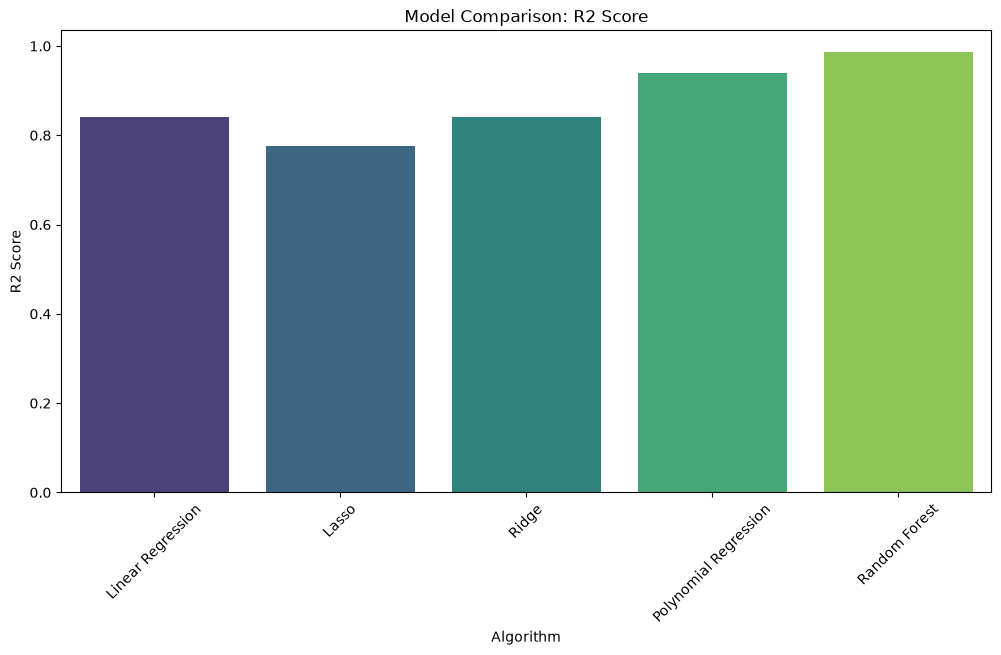

In [45]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Algorithm", y="R2 Score", data=df_results, palette="viridis")
plt.title("Model Comparison: R2 Score")
plt.xticks(rotation=45)
plt.show()

**Residual Plot Analysis**

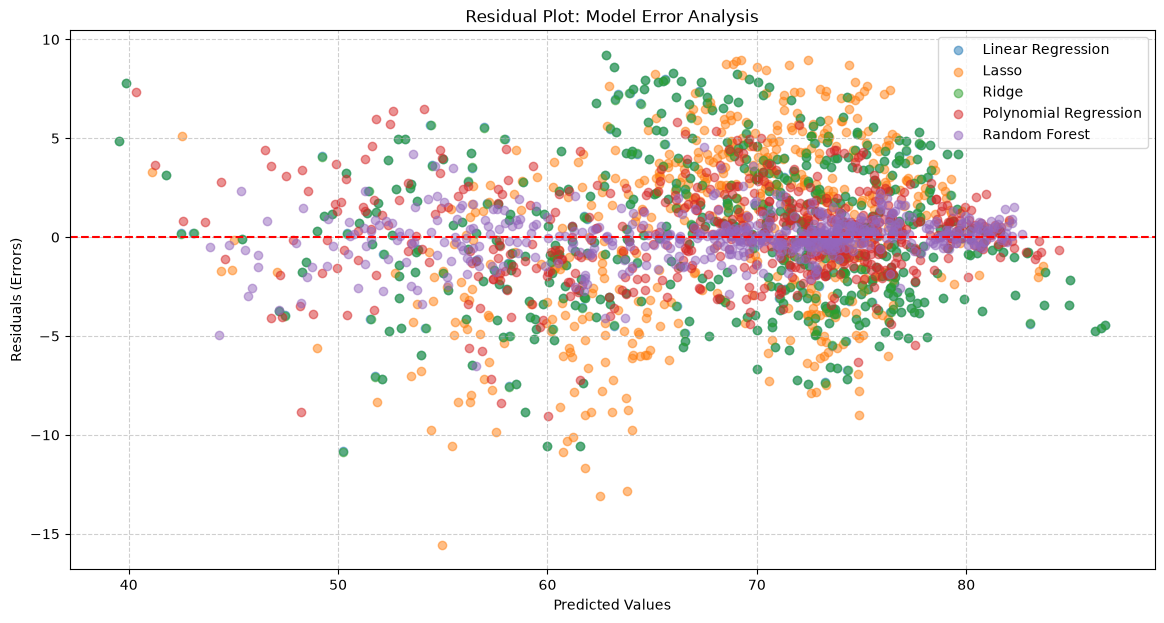

In [46]:
plt.figure(figsize=(14, 7))
for name, model, data in models_list:
    y_pred = model.predict(data)
    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals, alpha=0.5, label=name)

plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot: Model Error Analysis")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()